## Learning The Dataset

In [1]:
import pandas as pd

housing_data = pd.read_csv("train.csv")
housing_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [2]:
import matplotlib.pyplot as plt
# housing_data.hist(bins=50, figsize=(20,15))
# plt.show()

In [3]:
# housing_data.info()

## Splitting Training and Testing Data

### Splitting based on house prices category

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

saleprice_cat = pd.qcut(housing_data["SalePrice"], q=5, labels= [1, 2, 3, 4, 5])

sss = StratifiedShuffleSplit(n_splits=1, test_size = 0.2, random_state=42)
for train_index, test_index in sss.split(housing_data, saleprice_cat):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

## Splitting On Label

In [5]:
training_housing_data = strat_train_set.drop(columns="SalePrice")
training_housing_label = strat_train_set["SalePrice"].copy()

## Preparing The Data

### Simple Imputer (median for numbers and most frequent for objects), target encoding, standard scaler

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    # What fit does is to learn parameters for the data
    def fit(self, X, y=None):
        return self
    def transform(self, data):
        data = data.copy()
        data = data.drop(columns="Id")
        return data

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

num_attribs = list(training_housing_data.select_dtypes(include="number").columns)
num_attribs.remove('Id')

cat_attribs = list(training_housing_data.select_dtypes(include="object").columns)


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('standard_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('target', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('standard_scaler', StandardScaler())
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

In [8]:
# NOTE: NOT GOOD FOR THIS DATASET
# pipe = Pipeline([
#     ('custom', CustomTransformer()),
#     ('preprocess', preprocessing),
#     ('kmeans', KMeans(random_state=42, n_init=10)),
#     ('xgb', xgb)
# ])

# param_grid = {
#     'xgb__n_estimators': [100, 500],
#     'xgb__learning_rate': [0.01, 0.1],
#     'xgb__max_depth': [3, 5],
#     'xgb__subsample': [0.8, 1.0],
#     'kmeans__n_clusters': [2, 3, 4]
# }

# grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
# grid.fit(training_housing_data, training_housing_label)
# print(f"The best number of clusters for this regression is: {grid.best_params_['kmeans__n_clusters']}")

In [9]:
from sklearn.decomposition import PCA
full_pipeline = Pipeline([
    ('custom', CustomTransformer()),
    ('preprocess', preprocessing)
])
# Tambah PCA nanti abis ketemu feature importance

training_data = full_pipeline.fit_transform(training_housing_data, training_housing_label)
training_data

array([[-0.1515269 , -0.01745034, -0.27655235, ...,  0.04415452,
         0.321614  ,  0.21161851],
       [-0.87145947, -0.20530283,  0.34590278, ...,  0.04415452,
         0.321614  ,  0.21161851],
       [-0.1515269 ,  0.68699651,  0.02071713, ...,  0.04415452,
         0.321614  ,  0.21161851],
       ...,
       [-0.63148194, -0.9567128 , -0.55571404, ...,  0.04415452,
         0.321614  ,  0.21161851],
       [-0.87145947, -0.01745034,  0.00713629, ...,  0.04415452,
         0.321614  ,  0.21161851],
       [ 0.32842814, -0.01745034,  0.00907641, ...,  0.04415452,
         0.321614  ,  0.21161851]], shape=(1168, 79))

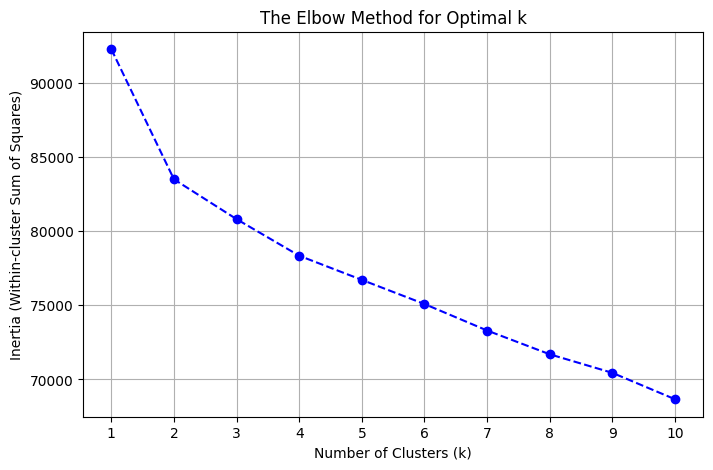

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Prepare a list of k values (e.g., 1 to 10)
k_values = range(1, 11)
inertias = []

# 2. Run KMeans for each k and store the inertia
for k in k_values:
    # n_init=10 is standard to ensure the algorithm finds a stable result
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(training_data) # Always use scaled data!
    inertias.append(kmeans.inertia_)

# 3. Create the Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [11]:
ct = full_pipeline.named_steps['preprocess']
final_training_data = pd.DataFrame(
    training_data, columns=ct.get_feature_names_out(), index=training_housing_data.index
)
final_training_data

,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,...,cat__GarageType,cat__GarageFinish,cat__GarageQual,cat__GarageCond,cat__PavedDrive,cat__PoolQC,cat__Fence,cat__MiscFeature,cat__SaleType,cat__SaleCondition
307,-0.151527,-0.017450,-0.276552,-0.066636,1.245540,-1.688380,-1.675110,-0.556745,-1.003301,-0.294416,...,-0.695782,0.947167,0.211346,0.182224,-3.570240,-0.055603,0.258184,0.044155,0.321614,0.211619
1341,-0.871459,-0.205303,0.345903,-0.066636,-0.513578,1.059099,0.911750,-0.556745,0.864582,-0.294416,...,1.563212,0.947167,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
1175,-0.151527,0.686997,0.020717,1.361453,-0.513578,0.694975,0.720131,1.280877,0.602987,-0.294416,...,-0.695782,-1.516733,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
349,0.088451,-0.674934,1.071939,2.075497,-0.513578,1.125303,1.007560,4.187266,2.232222,-0.294416,...,-0.695782,-1.516733,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,-0.924307,1.094370
621,0.088451,0.921812,0.033867,-0.066636,1.245540,0.099136,0.576416,-0.556745,1.190429,0.793712,...,-0.695782,-0.284783,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356,-0.871459,-0.017450,-0.108732,-0.780680,-0.513578,-0.165681,-0.908633,-0.202308,-0.223104,-0.294416,...,-0.695782,-0.284783,0.211346,0.182224,0.301664,-0.055603,-1.992252,0.044155,0.321614,0.211619
389,0.088451,1.203591,0.214298,2.789541,-0.513578,1.191508,1.103370,0.926440,1.933911,-0.294416,...,0.433715,-1.516733,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,-0.924307,1.094370
1323,-0.631482,-0.956713,-0.555714,-1.494725,1.245540,-1.026337,-1.675110,-0.556745,-0.360786,-0.294416,...,-0.695782,0.947167,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
33,-0.871459,-0.017450,0.007136,-0.780680,-0.513578,-0.397396,-1.243967,-0.556745,1.332701,-0.294416,...,-0.695782,-0.284783,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619


## Training Model

### Random forest, xgboost, linear regression, and SGD regressor

In [12]:
import xgboost
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

xgb = xgboost.XGBRegressor()
rf = RandomForestRegressor(random_state=42)
lr = LinearRegression()
sgd = SGDRegressor(random_state=42)

In [13]:
def display_scores(scores, model):
    print(model)
    print("Scores: ", scores)
    print("Mean ", scores.mean())

## Testing Importance

In [14]:
lr_model = lr.fit(final_training_data, training_housing_label)

In [15]:
importances = lr_model.coef_
feature_names = final_training_data.columns
feat_importances_dt = pd.Series(importances, index=feature_names)
feat_importances_dt.sort_values(ascending=False)

num__GrLivArea       14421.215273
num__OverallQual     13634.764744
num__2ndFlrSF        10629.188378
num__BsmtFinSF1       7950.676023
num__1stFlrSF         7858.609817
                         ...     
num__BedroomAbvGr    -4577.436146
cat__PoolQC          -4735.055040
cat__KitchenQual     -6083.154193
cat__ExterQual       -7011.243956
cat__BsmtQual        -8250.478934
Length: 79, dtype: float64

In [16]:
rf_model = rf.fit(final_training_data, training_housing_label)

## Grid Search

In [17]:
import joblib

def show_result(grid, name):
    print("Score: ", np.sqrt(-grid.best_score_))
    print("Parameter: ", grid.best_params_)
    joblib.dump(grid.best_estimator_, name)

In [18]:
# Random Forest
from sklearn.model_selection import GridSearchCV

rf_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 2, 4, 6]
}

rf_grid = GridSearchCV(
    rf,
    rf_param,
    scoring='neg_mean_squared_error',   
    n_jobs = -1,
    cv=3
)

RUN = False
if RUN:
    rf_grid.fit(final_training_data, training_housing_label)
    show_result(rf_grid, "rf_best_estimator.joblib")
# Score:  31573.78875397735
# Parameter:  {'max_depth': None, 'n_estimators': 300, 'random_state': 42}

In [19]:
sgd_param = {
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.00001, 0.0001, 0.001, 0.01],
    'early_stopping': [True, False],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'max_iter': [1000, 2000]
}

sgd_grid = GridSearchCV(
    sgd,
    sgd_param,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=3
)

RUN = False
if RUN:
    sgd_grid.fit(final_training_data, training_housing_label)
    show_result(sgd_grid, "sgd_best_estimator.joblib")

# Score:  33107.65244725026
# Parameter:  {'alpha': 0.01, 'early_stopping': False, 'learning_rate': 'invscaling', 'max_iter': 1000, 'penalty': 'l2'}


In [20]:
xgb_param = {
    'n_estimators': [100, 500],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=3
)

RUN=False
if RUN:
    xgb_grid.fit(final_training_data, training_housing_label)
    show_result(xgb_grid, "xgb_best_estimator.joblib")

# Score:  30793.123041787538
# Parameter:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}

## Data Testing

In [21]:
test_data = strat_test_set.drop(columns="SalePrice")
test_label = strat_test_set["SalePrice"].copy()

In [22]:
test_data_pipeline = full_pipeline.transform(test_data)

In [23]:
ct = full_pipeline.named_steps['preprocess']
final_testing_data = pd.DataFrame(
    test_data_pipeline, columns=ct.get_feature_names_out(), index=test_data.index
)
final_testing_data

,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,...,cat__GarageType,cat__GarageFinish,cat__GarageQual,cat__GarageCond,cat__PavedDrive,cat__PoolQC,cat__Fence,cat__MiscFeature,cat__SaleType,cat__SaleCondition
1028,-0.151527,0.405218,-0.107115,-0.780680,-0.513578,-0.993235,-1.675110,-0.556745,-0.158853,-0.049289,...,-0.695782,0.947167,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
1101,-0.871459,-0.440118,-0.078445,-0.780680,-0.513578,-0.000170,-0.669109,-0.556745,-0.057886,1.421478,...,1.563212,0.947167,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
1196,0.088451,-0.581008,0.384597,0.647408,-0.513578,1.158405,1.007560,-0.556745,-1.003301,-0.294416,...,0.433715,-1.516733,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,-0.924307,1.094370
1007,2.488226,-2.318643,-0.891247,-1.494725,-1.393137,-0.033272,-0.717014,-0.556745,-0.376849,1.337776,...,-0.695782,-0.284783,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
1317,1.528316,-1.097602,-0.674277,0.647408,-0.513578,1.158405,1.055465,-0.556745,-1.003301,-0.294416,...,-0.695782,-0.284783,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,-0.924307,1.094370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,0.568406,-0.017450,0.091316,-0.066636,-0.513578,0.165341,-0.429585,-0.556745,0.233540,-0.294416,...,-0.695782,-0.284783,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
598,-0.871459,0.452181,0.269268,-0.780680,0.365981,0.198443,-0.381680,1.946129,1.940795,0.584456,...,-0.695782,-1.516733,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
1361,-0.871459,2.518558,0.611376,0.647408,-0.513578,1.125303,0.959655,-0.469499,1.920143,-0.294416,...,-0.695782,-1.516733,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,0.321614,0.211619
83,-0.871459,0.452181,-0.171786,-0.780680,-0.513578,-0.364294,-1.196062,-0.196855,-1.003301,-0.294416,...,1.563212,0.947167,0.211346,0.182224,0.301664,-0.055603,0.258184,0.044155,-4.662070,0.211619


In [24]:
from sklearn.ensemble import VotingRegressor

lr_best = lr.fit(final_training_data, training_housing_label)
rf_best = joblib.load("rf_best_estimator.joblib")
sgd_best= joblib.load("sgd_best_estimator.joblib")
xgb_best = joblib.load("xgb_best_estimator.joblib")

voting_regressor = VotingRegressor(
    estimators=[('lr', lr_best), ('rf', rf_best), ('sgd', sgd_best), ('xgb', xgb_best)]
)
voting_regressor.fit(final_training_data, training_housing_label)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,n_estimators,300
,criterion,'squared_error'


In [25]:
from sklearn.metrics import mean_squared_error

for model in (lr_best, rf_best, sgd_best, xgb_best, voting_regressor):
    y_pred = model.predict(final_testing_data)
    print(model.__class__.__name__, np.sqrt(mean_squared_error(test_label, y_pred)))
# XGBRegressor is chosen

LinearRegression 42002.10244599006
RandomForestRegressor 29629.2484546137
SGDRegressor 41905.556991278645
XGBRegressor 23839.10065417737
VotingRegressor 31738.54532870542


## Submission

In [34]:
kaggle_test = pd.read_csv("test.csv")
kaggle_pipeline = full_pipeline.transform(kaggle_test)

In [27]:
y_pred = xgb_best.predict(kaggle_pipeline)
y_pred

array([120976.914, 172324.73 , 180916.33 , ..., 157178.62 , 124523.83 ,
       213356.69 ], shape=(1459,), dtype=float32)

In [35]:
df = pd.DataFrame({
    "Id": kaggle_test["Id"].astype(int),
    "SalePrice": y_pred
})
df

,Id,SalePrice
0,1461,120976.914062
1,1462,172324.734375
2,1463,180916.328125
3,1464,189728.187500
4,1465,207263.750000
...,...,...
1454,2915,82400.929688
1455,2916,84473.992188
1456,2917,157178.625000
1457,2918,124523.828125


In [36]:
df.to_csv("prediction.csv", index=False)